In [109]:
import pandas as pd

In [110]:
import numpy as np

1. Load Dataset

In [112]:
df=pd.read_csv("final_fraud_dataset.csv")
df

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,DeviceType,DeviceInfo
0,0,86400,68.500,4,13926,361,150,2,142,2,315,87,19,37,0,0,0,1557
1,0,86401,29.000,4,2755,404,150,3,102,2,325,87,8,37,17,0,0,1557
2,0,86469,59.000,4,4663,490,150,4,166,3,330,87,287,37,36,0,0,1557
3,0,86499,50.000,4,18132,567,150,3,117,3,476,87,8,37,54,0,0,1557
4,0,86506,50.000,1,4497,514,150,3,102,2,420,87,8,37,17,0,2,954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529306,0,13919189,67.950,4,2987,555,150,4,226,2,494,87,8,37,0,0,0,1557
529307,0,13919203,52.950,4,4806,490,150,4,226,3,315,87,8,37,54,0,0,1557
529308,0,13919219,56.316,0,13832,375,185,3,224,3,299,87,8,37,20,20,2,1190
529309,1,13919221,30.371,0,5347,408,185,3,102,3,299,87,8,37,17,17,1,1557


2. Basic EDA

In [114]:
df.shape

(529311, 18)

In [115]:
df.size

9527598

In [116]:
df.info

<bound method DataFrame.info of         isFraud  TransactionDT  TransactionAmt  ProductCD  card1  card2  \
0             0          86400          68.500          4  13926    361   
1             0          86401          29.000          4   2755    404   
2             0          86469          59.000          4   4663    490   
3             0          86499          50.000          4  18132    567   
4             0          86506          50.000          1   4497    514   
...         ...            ...             ...        ...    ...    ...   
529306        0       13919189          67.950          4   2987    555   
529307        0       13919203          52.950          4   4806    490   
529308        0       13919219          56.316          0  13832    375   
529309        1       13919221          30.371          0   5347    408   
529310        0       13919223         365.000          4  11207    361   

        card3  card4  card5  card6  addr1  addr2  dist1  dist2  P_e

In [117]:
df.dtypes

isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD           int64
card1               int64
card2               int64
card3               int64
card4               int64
card5               int64
card6               int64
addr1               int64
addr2               int64
dist1               int64
dist2               int64
P_emaildomain       int64
R_emaildomain       int64
DeviceType          int64
DeviceInfo          int64
dtype: object

In [118]:
df.describe()

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,DeviceType,DeviceInfo
count,529311.000000,5.293110e+05,529311.000000,529311.000000,529311.000000,529311.000000,529311.000000,529311.000000,529311.000000,529311.000000,529311.000000,529311.000000,529311.000000,529311.000000,529311.000000,529311.000000,529311.000000,529311.000000
mean,0.034743,6.508350e+06,134.791403,3.208505,9874.931706,362.273206,153.212425,3.601960,199.710431,2.738732,291.579134,86.809518,52.411833,49.872071,20.243260,4.555488,0.334512,1521.046833
std,0.183129,4.068363e+06,237.960590,1.431553,4896.115711,156.721075,11.348603,0.620981,40.853416,0.459307,96.066565,2.622128,241.541655,145.219571,18.124279,10.704280,0.640971,205.514616
min,0.000000,8.640000e+04,0.251000,0.000000,1000.000000,100.000000,100.000000,0.000000,100.000000,0.000000,100.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.647706e+06,43.382000,3.000000,6019.000000,215.000000,150.000000,3.000000,166.000000,2.000000,205.000000,87.000000,8.000000,37.000000,3.000000,0.000000,0.000000,1557.000000
50%,0.000000,6.392254e+06,68.561000,4.000000,9633.000000,361.000000,150.000000,4.000000,226.000000,3.000000,299.000000,87.000000,8.000000,37.000000,17.000000,0.000000,0.000000,1557.000000
75%,0.000000,1.000264e+07,125.000000,4.000000,14128.000000,512.000000,150.000000,4.000000,226.000000,3.000000,327.000000,87.000000,8.000000,37.000000,20.000000,0.000000,0.000000,1557.000000
max,1.000000,1.391922e+07,31937.391000,4.000000,18396.000000,600.000000,231.000000,4.000000,237.000000,4.000000,540.000000,102.000000,10286.000000,11623.000000,59.000000,60.000000,2.000000,1786.000000


Drop Unnecessary Columns

In [120]:
df.drop(['card1','card2','card3','card4','card5','card6','addr1','addr2','dist1','dist2'],axis=1, inplace=True)
df

,isFraud,TransactionDT,TransactionAmt,ProductCD,P_emaildomain,R_emaildomain,DeviceType,DeviceInfo
0,0,86400,68.500,4,0,0,0,1557
1,0,86401,29.000,4,17,0,0,1557
2,0,86469,59.000,4,36,0,0,1557
3,0,86499,50.000,4,54,0,0,1557
4,0,86506,50.000,1,17,0,2,954
...,...,...,...,...,...,...,...,...
529306,0,13919189,67.950,4,0,0,0,1557
529307,0,13919203,52.950,4,54,0,0,1557
529308,0,13919219,56.316,0,20,20,2,1190
529309,1,13919221,30.371,0,17,17,1,1557


In [121]:
df.isnull().sum()

isFraud           0
TransactionDT     0
TransactionAmt    0
ProductCD         0
P_emaildomain     0
R_emaildomain     0
DeviceType        0
DeviceInfo        0
dtype: int64

In [122]:
df['isFraud'].value_counts()

isFraud
0    510921
1     18390
Name: count, dtype: int64

Basic EDA Visualizations

Fraud Count

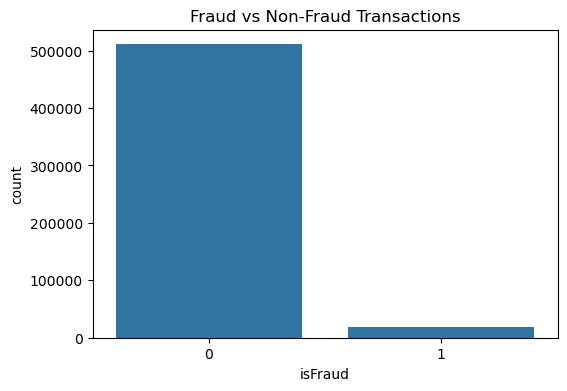

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

Transaction Amount Analysis

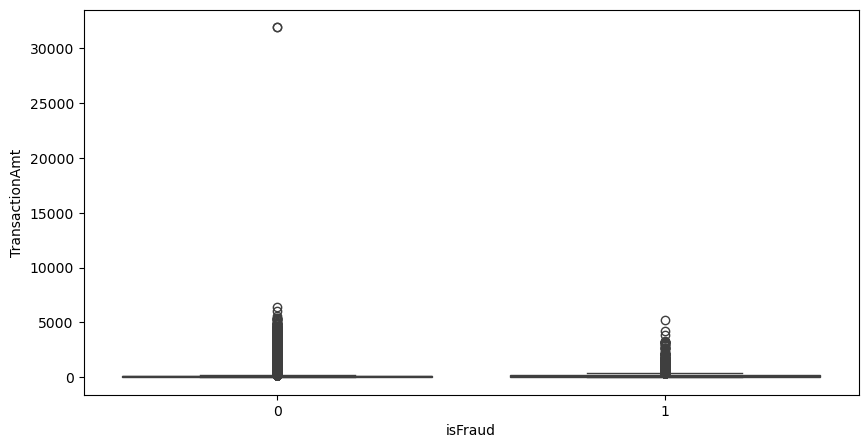

In [127]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='isFraud',
    y='TransactionAmt',
    data=df
)

plt.show()

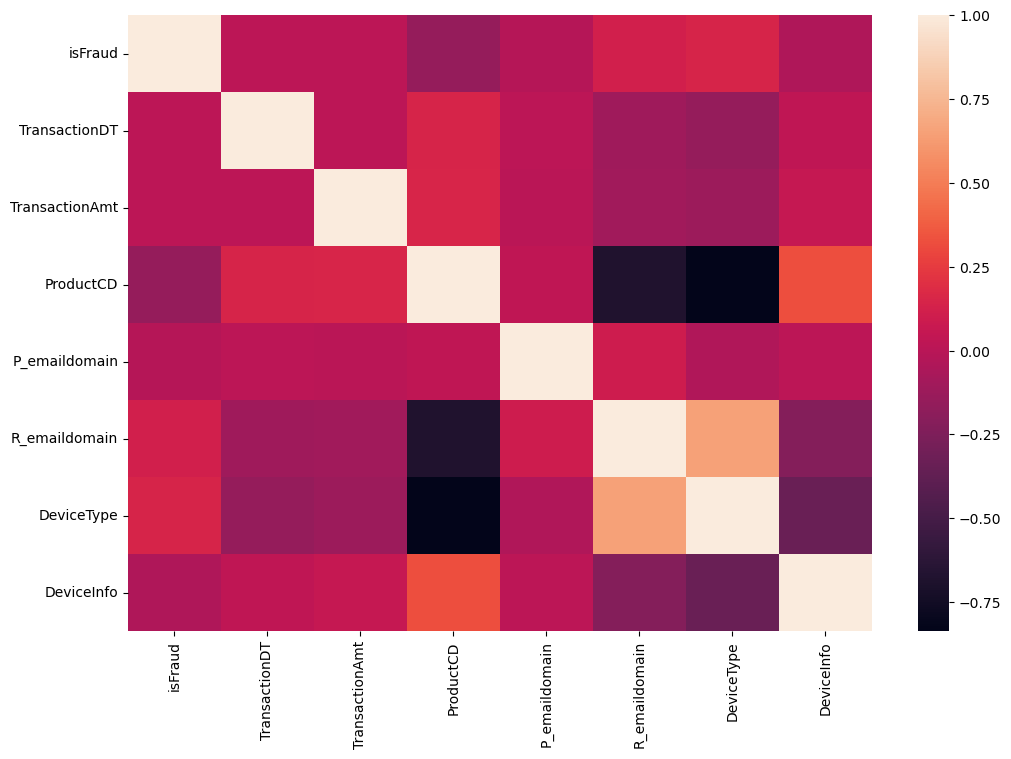

In [128]:
corr = df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr)

plt.show()

Feature and Target Separation

In [130]:
x = df.drop('isFraud', axis=1)
y = df['isFraud']

In [131]:
x

,TransactionDT,TransactionAmt,ProductCD,P_emaildomain,R_emaildomain,DeviceType,DeviceInfo
0,86400,68.500,4,0,0,0,1557
1,86401,29.000,4,17,0,0,1557
2,86469,59.000,4,36,0,0,1557
3,86499,50.000,4,54,0,0,1557
4,86506,50.000,1,17,0,2,954
...,...,...,...,...,...,...,...
529306,13919189,67.950,4,0,0,0,1557
529307,13919203,52.950,4,54,0,0,1557
529308,13919219,56.316,0,20,20,2,1190
529309,13919221,30.371,0,17,17,1,1557


In [132]:
y

0         0
1         0
2         0
3         0
4         0
         ..
529306    0
529307    0
529308    0
529309    1
529310    0
Name: isFraud, Length: 529311, dtype: int64

Train-Test Split

In [134]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20)
x_train

,TransactionDT,TransactionAmt,ProductCD,P_emaildomain,R_emaildomain,DeviceType,DeviceInfo
211039,4898220,117.000,4,3,0,0,1557
315051,7848781,39.000,4,20,0,0,1557
31675,778464,49.000,4,0,0,0,1557
337988,8304543,117.000,4,0,0,0,1557
257159,6159726,30.950,4,54,0,0,1557
...,...,...,...,...,...,...,...
123848,2429411,28.217,0,20,20,2,1557
317380,7912977,57.950,4,17,0,0,1557
145753,3003944,227.560,4,17,0,0,1557
74589,1639225,44.308,0,17,17,2,1415


In [135]:
x_test

,TransactionDT,TransactionAmt,ProductCD,P_emaildomain,R_emaildomain,DeviceType,DeviceInfo
221500,5201127,108.43,4,36,0,0,1557
159412,3352834,50.00,1,54,17,2,1728
118304,2313038,117.85,4,20,0,0,1557
213404,4973945,107.95,4,17,0,0,1557
521327,13703716,226.00,4,17,0,0,1557
...,...,...,...,...,...,...,...
467276,12042090,28.47,4,54,0,0,1557
104120,2070321,117.00,4,17,0,0,1557
413865,10444393,39.54,4,0,0,0,1557
130905,2591067,445.00,4,3,0,0,1557


In [136]:
y_train

211039    0
315051    0
31675     0
337988    0
257159    0
         ..
123848    0
317380    0
145753    0
74589     0
144968    0
Name: isFraud, Length: 423448, dtype: int64

In [137]:
y_test

221500    0
159412    0
118304    0
213404    0
521327    0
         ..
467276    0
104120    0
413865    0
130905    0
203344    0
Name: isFraud, Length: 105863, dtype: int64

SMOTE

In [138]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train
)

print(y_train_smote.value_counts())

isFraud
0    408815
1    408815
Name: count, dtype: int64


In [139]:
pip install xgboost

Train XGBoost Model

In [140]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

model.fit(x_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Make Predictions

In [141]:
y_pred = model.predict(x_test)

y_prob = model.predict_proba(x_test)[:,1]

Hyperparameter Tuning

In [142]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

params = {
    'n_estimators':[100,200,300],
    'max_depth':[4,6,8],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.8,1.0],
    'colsample_bytree':[0.8,1.0]
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

search = RandomizedSearchCV(
    xgb,
    param_distributions=params,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=1
)

search.fit(x_train_smote, y_train_smote)

print(search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [143]:
print(model.predict([[13656787,425.76,4,22,0,2,1557]]))

[1]


Evaluate Model

In [144]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95    102106
           1       0.18      0.45      0.25      3757

    accuracy                           0.91    105863
   macro avg       0.58      0.69      0.60    105863
weighted avg       0.95      0.91      0.93    105863



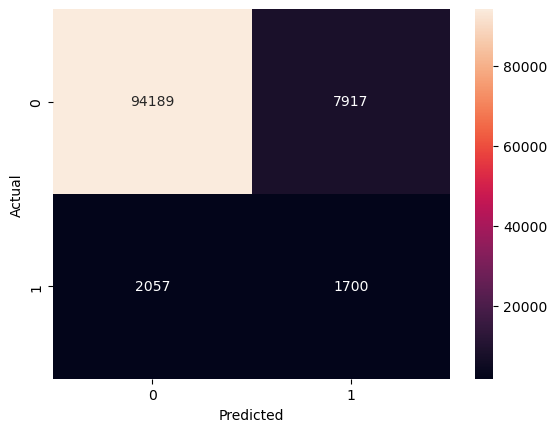

In [145]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [146]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.7838665273878304

In [147]:
from sklearn.metrics import precision_score

precision_score(y_test, y_pred)

0.176770302589165

In [148]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred)

0.45248868778280543

In [149]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

In [150]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_prob)

print("Brier Score:", brier)

Brier Score: 0.07763946189797691


In [151]:
from sklearn.metrics import average_precision_score

auc_pr = average_precision_score(y_test, y_prob)

print("AUC-PR:", auc_pr)

AUC-PR: 0.19891989263738183


In [152]:
print("Roc_auc_score",roc_auc_score(y_test, y_prob))
print("Average_precision_score",average_precision_score(y_test, y_prob))
print("Brier_score_loss",brier_score_loss(y_test, y_prob))
print("Confusion_matrix",confusion_matrix(y_test, y_pred))

Roc_auc_score 0.7838665273878304
Average_precision_score 0.19891989263738183
Brier_score_loss 0.07763946189797691
Confusion_matrix [[94189  7917]
 [ 2057  1700]]
